# Analyse du risque de sous-staff / sur-staff

Ce notebook utilise le contexte du pipeline `pipeline_entrepot` pour travailler avec les mêmes pôles opérationnels : `BULK`, `PICKING`, `PROMO`, `GLOBAL`.
Il calcule les besoins en heures à partir des volumes prévus par pôle et des productivités, puis compare ces besoins à la capacité disponible.

Résumé des besoins et de la capacité par pôle :


,Volume prévu,Productivité (OL/h),Besoin (h),Capacité (h),Écart (h),Ratio
BULK,5000,26.5,188.679245,50.0,-138.679245,0.265000
PICKING,12000,157.0,76.433121,80.0,3.566879,1.046667
PROMO,8000,125.0,64.000000,70.0,6.000000,1.093750
GLOBAL,6000,27.6,217.391304,50.0,-167.391304,0.230000
TOTAL,31000,,546.503671,250.0,-296.503671,0.457453


>> Risque global de sous-staff. La capacité totale est inférieure au besoin total.
>> Risque de sous-staff sur BULK (ratio 0.27)
>> Sur-staff sur PICKING (ratio 1.05)
>> Sur-staff sur PROMO (ratio 1.09)
>> Risque de sous-staff sur GLOBAL (ratio 0.23)


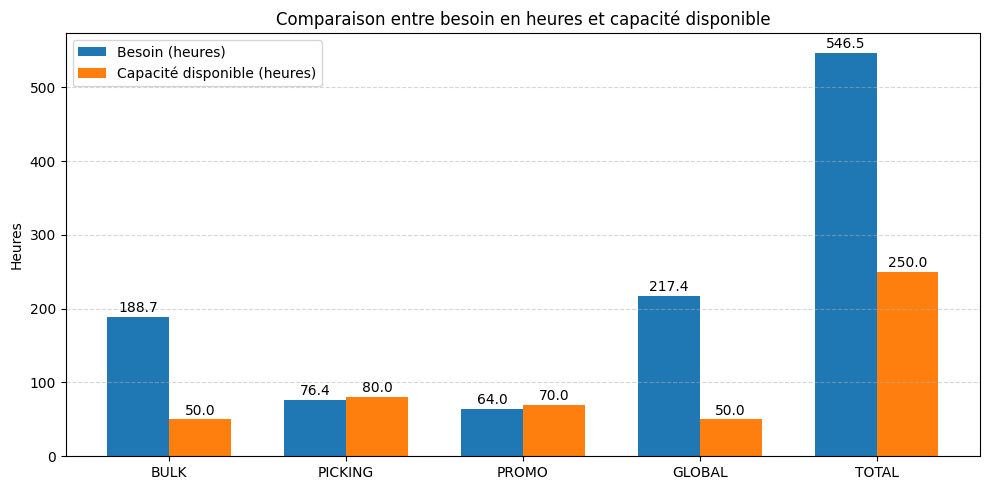

In [4]:
# Pôles opérationnels en lien avec le notebook pipeline_entrepot
POLES = ['BULK', 'PICKING', 'PROMO', 'GLOBAL']

# Productivités (OL par heure) par pôle
productivities = {
    'PICKING': 157.0,
    'PROMO': 125.0,
    'BULK': 26.5,
    'GLOBAL': 27.6,
}

# Volumes prévus par pôle (OL)
forecast_volumes = {
    'PICKING': 12000,
    'PROMO': 8000,
    'BULK': 5000,
    'GLOBAL': 6000,
}

# Capacité disponible par pôle si vous souhaitez comparer secteur par secteur
available_hours_by_pole = {
    'PICKING': 80.0,
    'PROMO': 70.0,
    'BULK': 50.0,
    'GLOBAL': 50.0,
}

import pandas as pd
import matplotlib.pyplot as plt

def compute_need(volumes, productivities):
    return {pole: volumes[pole] / productivities[pole] for pole in volumes}

need_hours = compute_need(forecast_volumes, productivities)
total_need = sum(need_hours.values())

total_capacity = sum(available_hours_by_pole.values())

summary = pd.DataFrame(index=POLES, data={
    'Volume prévu': [forecast_volumes[p] for p in POLES],
    'Productivité (OL/h)': [productivities[p] for p in POLES],
    'Besoin (h)': [need_hours[p] for p in POLES],
    'Capacité (h)': [available_hours_by_pole[p] for p in POLES],
})
summary['Écart (h)'] = summary['Capacité (h)'] - summary['Besoin (h)']
summary['Ratio'] = summary['Capacité (h)'] / summary['Besoin (h)']

summary_display = summary.copy()
summary_display.loc['TOTAL'] = {
    'Volume prévu': summary['Volume prévu'].sum(),
    'Productivité (OL/h)': '',
    'Besoin (h)': total_need,
    'Capacité (h)': total_capacity,
    'Écart (h)': total_capacity - total_need,
    'Ratio': total_capacity / total_need if total_need else float('inf'),
}

print('Résumé des besoins et de la capacité par pôle :')
display(summary_display)

if total_capacity < total_need:
    print('>> Risque global de sous-staff. La capacité totale est inférieure au besoin total.')
elif total_capacity > total_need:
    print('>> Risque global de sur-staff. La capacité totale dépasse le besoin total.')
else:
    print('>> Capacité globale équilibrée avec le besoin total.')

for pole in POLES:
    ratio = summary.loc[pole, 'Ratio']
    if ratio < 1:
        print(f'>> Risque de sous-staff sur {pole} (ratio {ratio:.2f})')
    elif ratio > 1:
        print(f'>> Sur-staff sur {pole} (ratio {ratio:.2f})')
    else:
        print(f'>> Équilibre sur {pole} (ratio 1.00)')

# Diagramme à barres comparaison besoins vs capacité par pôle
categories = POLES + ['TOTAL']
values_need = [need_hours[p] for p in POLES] + [total_need]
values_capacity = [available_hours_by_pole[p] for p in POLES] + [total_capacity]

x = range(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([xi - width/2 for xi in x], values_need, width, label='Besoin (heures)')
ax.bar([xi + width/2 for xi in x], values_capacity, width, label='Capacité disponible (heures)')

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Heures')
ax.set_title('Comparaison entre besoin en heures et capacité disponible')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

for xi, value in zip([xi - width/2 for xi in x], values_need):
    ax.text(xi, value + max(values_capacity) * 0.01, f'{value:.1f}', ha='center', va='bottom')
for xi, value in zip([xi + width/2 for xi in x], values_capacity):
    ax.text(xi, value + max(values_capacity) * 0.01, f'{value:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Instructions d'utilisation
1. Remplace les volumes prévus dans `forecast_volumes` par tes propres prévisions ou par les prédictions issues du pipeline `pipeline_entrepot`.
2. Ajuste `available_hours_by_pole` ou la capacité totale selon ta planification réelle.
3. Relance la cellule pour voir si le staffing est en sous-staff ou en sur-staff, globalement et par pôle.